# Sprint 1 Notebook
- Replace the work from `Sprint1_TG` notebook <br>

- Recreate PCA & Clustering from Sprint 1
- 

In [1]:
!ls '/project_data/data_asset'
# these are the data files that are available to us
# they can be loaded into this notebook by using the `0100` button in the top right corner

arcgis_creds_alex.json		   op_analysis_04012018_06302018.csv
colorado-latest.osm.bz2		   op_analysis_04012019_06302019.csv
connect_oracle_db.R		   op_analysis_07012018_09302018.csv
creds.json			   op_analysis_07012019_09302019.csv
joined_df.csv			   op_analysis_10012018_12312018.csv
ojdbc6.jar			   op_analysis_10012019_12312019.csv
op_analysis_01012018_03312018.csv  op_analysis.csv
op_analysis_01012019_03312019.csv  op_analysis_with_nulls.csv
op_analysis_01012020_03312020.csv  op_analysis_with_nulls_with_labels.csv


In [2]:
# import some libraries into the notebook
# all these libraries are pre-installed in Cloud Pak for Data

import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
import sys

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.pyplot import figure
%matplotlib inline

# Recreate Sprint 1 PCA and Clustering
- Preprocessing (drop cols, scaling, fillna)
- PCA and keep 3 components (from the first sprint)
- kmeans clustering (5 clusters from first sprint)


In [3]:
# load data that I used in sprint 1

df_sprint1 = pd.read_csv('/project_data/data_asset/op_analysis_with_nulls.csv')
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,4.560606,0.048077,NaN,NaN,NaN,NaN,NaN,1.000000,0.860000,NaN,NaN,NaN,NaN,0.5,NaN,0.142857,NaN,NaN,0.285714,NaN,NaN
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,8.644444,0.231405,NaN,NaN,NaN,NaN,NaN,0.375000,0.862857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,4.546512,0.062500,NaN,NaN,NaN,NaN,0.044444,0.937500,0.928571,NaN,NaN,NaN,0.222222,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,4.639535,0.220930,NaN,NaN,NaN,NaN,0.022222,0.909091,0.676471,NaN,NaN,NaN,0.047619,NaN,NaN,0.047619,NaN,NaN,0.333333,NaN,NaN
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,8.887500,0.695652,NaN,NaN,NaN,NaN,0.090909,0.400000,0.636364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.272727,NaN,NaN


In [4]:
# check missing count per column

df_sprint1.isna().mean()

Member Count              0.000000
Count Script              0.000000
Sum Dispensed Quantity    0.000000
Max Dispense Date         0.000000
Min Dispense Date         0.000000
PRSCRB_PROV_LOC_ID        0.000000
Total Days                0.000000
PR2                       0.000000
PR1                       0.000000
PR4                       0.000000
PR3                       0.000000
PR5                       0.184077
PR6                       0.861470
PR7                       0.860488
PR8                       0.966312
PR9                       0.995241
PR10                      0.847723
PR11                      0.318302
PR13                      0.023869
PR15                      1.000000
PR18                      0.999245
PR19                      0.989727
PR21                      0.877106
PR23                      0.933001
PR24                      0.984893
PR25                      0.781177
PR26                      0.980437
PR27                      0.999622
PR28                

### Preprocessing

In [5]:
# make lists of indicies and features for preprocessing pipeline

to_drop = []
index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date']
features = [c for c in df_sprint1.columns if c not in index or to_drop]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [6]:
# drop columns with >= 80% of data missing to get the same result i had before

remove_missing_cols = df_sprint1.isna().mean().sort_values(ascending=False).to_frame().rename({0:'Percent_Missing'}, axis=1)
remove_missing_cols = remove_missing_cols.loc[remove_missing_cols['Percent_Missing'] >=.80]
to_drop += remove_missing_cols.index.to_list()
print('Number of features to remove: ', len(to_drop))



Number of features to remove:  15


In [7]:
# redefine columns

features = [c for c in df_sprint1.columns if c not in to_drop+index]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [8]:
# this is the final lisr of features (metrics) we will use
    #should we feed these counts into algorithm or just PR metrics?
num_features

['Member Count',
 'Count Script',
 'Sum Dispensed Quantity',
 'Total Days',
 'PR2',
 'PR1',
 'PR4',
 'PR3',
 'PR5',
 'PR11',
 'PR13',
 'PR25',
 'PR28']

In [9]:
# define a preprocessor
# handle scaling and imputation

def preprocessor_sprint1(list_of_numerical_features):
    '''
    num_features is a python list of numerical features
    '''
    scaler = StandardScaler() # use robust or standard
    
    numerical_pipeline = make_pipeline(SimpleImputer(strategy='mean'), scaler)
    
    preprocessor = make_column_transformer((numerical_pipeline, list_of_numerical_features), remainder='drop')
    
    return preprocessor

In [10]:
# call the preprocessor
# see that the preprocessor is working
preprocessor_sprint1_regen = preprocessor_sprint1(num_features)

tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_sprint1[num_features])
df_sprint1_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_sprint1[c].isna().all()==False], index=df_sprint1.index)
df_sprint1_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR11,PR13,PR25,PR28
0,-0.128741,-0.240949,-0.191785,0.435770,-0.710371,-0.322177,-0.569270,-0.314132,-0.665099,1.650310,0.257354,-0.706362,-0.512036
1,0.107514,0.109065,-0.044891,1.162167,0.609609,0.016769,-0.309302,-0.215433,0.309113,-0.634730,0.275955,0.000000,0.000000
2,-0.010614,-0.055648,-0.164069,1.041101,0.158334,-0.316744,-0.439799,-0.314473,-0.588454,1.421806,0.703778,0.000000,0.000000
3,0.698151,0.067887,-0.161605,1.041101,-0.657185,-0.615560,-0.326869,-0.312225,0.253450,1.317941,-0.937485,-1.608412,-0.276476
4,0.107514,0.026709,-0.065524,0.859502,0.203462,-0.057688,-0.336280,-0.209559,2.776140,-0.543328,-1.198595,0.000000,-0.576279


### PCA
- The scikit-learn library has PCA built in and I will use this library
    - [Here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) is the web API 

In [11]:
# start will the maximum number of components
# this helps to show us all the variance per component

pca = PCA(n_components=df_sprint1_processed.shape[1]) #Initialize PCA with components = number variables in preprocessed dataframe
tmp_pca = pca.fit_transform(df_sprint1_processed) #Call fit_transform method to apply PCA

# now we have the same result as we had in Sprint 1
# this can be read as, "First component explains 35.5% of variance in the data, second component explains 17.8% of variance in the data, ..."
# I will choose the first 3 to keep things simple and make clustering easily visual

pca.explained_variance_ratio_

array([0.35486976, 0.17783763, 0.12073398, 0.09813014, 0.06419088,
       0.05390923, 0.04574481, 0.03004992, 0.0248711 , 0.0136479 ,
       0.00877099, 0.00577818, 0.00146548])

In [12]:
# the variable `num_components_tokeep` can be changed to include more or less components for the clustering
# using the variable makes it easier for us to change if we want

num_components_tokeep = 3
df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_tokeep], columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], index=df_sprint1_processed.index)
df_for_clustering.head()

,Comp 1,Comp 2,Comp 3
0,-0.802109,0.124486,-0.765940
1,0.337385,-1.147698,0.025992
2,-0.431189,-0.164391,-1.107504
3,0.030948,-0.096998,0.755144
4,0.269009,-0.933088,2.821131


### Clustering
- [Here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) is the link to the scikit-learn library API for KMeans clustering

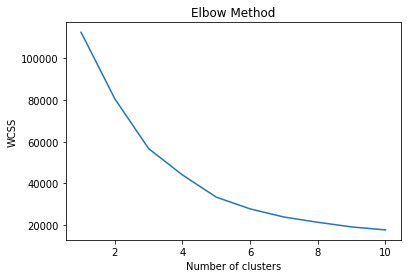

In [13]:
# make the Elbow Plot to see what is the ideal number of clusters

wcss = [] # within cluster sum of squares (sum of squared distance to cluster centroid)
for i in range(1, 11):
    #run k-means for clusters 1 - 11
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=12) 
    kmeans.fit(df_for_clustering)
    wcss.append(kmeans.inertia_) #inertia = wcss
plt.plot(range(1, 11), wcss)
#The elbow point indicates the number of clusters at which we've explained much of the variation in the
# reduced dataset without separating the data too much (with each observation being assigned to their own cluster 
# being maximum number of clusters and pretty pointless)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [14]:
#init = 'random' or 'kmeans++' - Should probably read additional notes but it looks like kmeans++
#is related to speeding up performance on larger datasets?

#n_init - number of times k-means is run with different centroid seeds
#max_iter - maximum number of iterations
#random_state - akin to setting seed so results are reproducible

In [15]:
# IMO, 5 is the ideal number of clusters, so that is how many i will use
number_of_clusters = 5

kmeans = KMeans(n_clusters=number_of_clusters, random_state=12) # make the clustering
kmeans.fit(df_for_clustering) # fit the clustering to the data
y_kmeans = kmeans.predict(df_for_clustering) # predict to get the labels

#### Plot the clusters

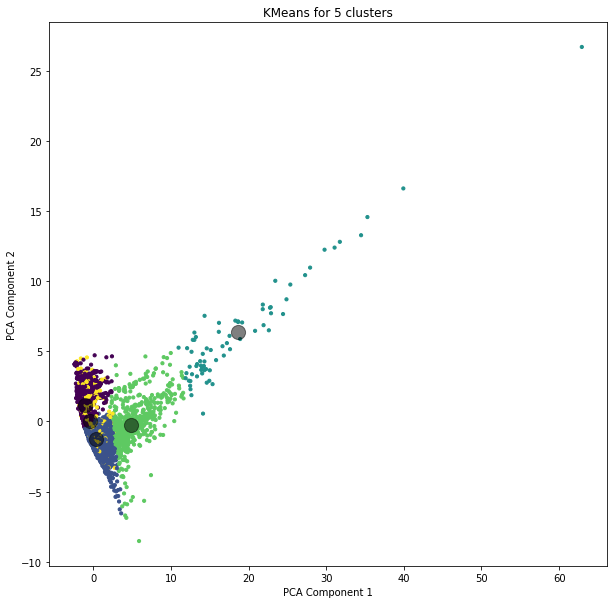

In [16]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 1], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show();

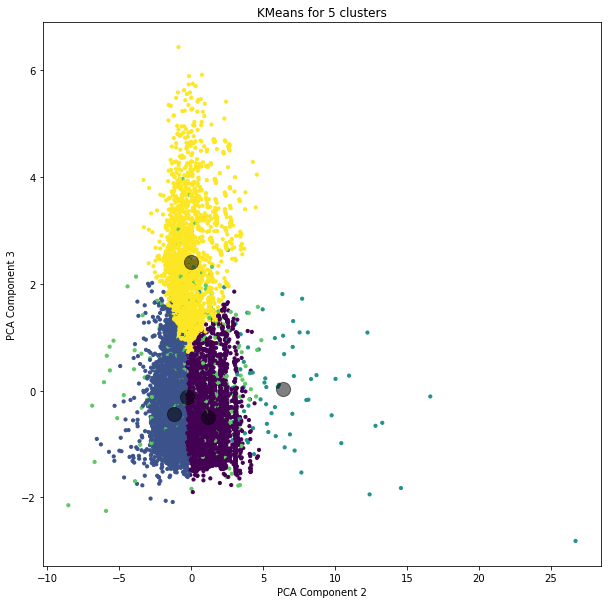

In [17]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 1], df_for_clustering.iloc[:, 2], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 2')
plt.ylabel('PCA Component 3')
plt.show();

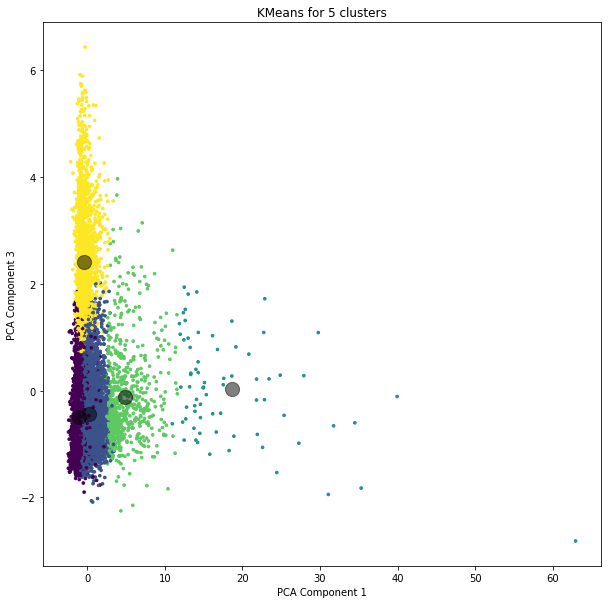

In [18]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 2], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 3')

plt.show();

In [19]:
# calculate silhouette score of this clustering algorithm
sil_score = round(silhouette_score(df_for_clustering, y_kmeans), 3)
print(f'Silhouette score for 5 clusters is {sil_score}')

Silhouette score for 5 clusters is 0.403


## Map the cluster label back to the original data

In [20]:
df_sprint1['Cluster_label'] = pd.Series(y_kmeans, index=df_sprint1.index)
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,4.560606,0.048077,NaN,NaN,NaN,NaN,NaN,1.000000,0.860000,NaN,NaN,NaN,NaN,0.5,NaN,0.142857,NaN,NaN,0.285714,NaN,NaN,0
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,8.644444,0.231405,NaN,NaN,NaN,NaN,NaN,0.375000,0.862857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,4.546512,0.062500,NaN,NaN,NaN,NaN,0.044444,0.937500,0.928571,NaN,NaN,NaN,0.222222,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,4.639535,0.220930,NaN,NaN,NaN,NaN,0.022222,0.909091,0.676471,NaN,NaN,NaN,0.047619,NaN,NaN,0.047619,NaN,NaN,0.333333,NaN,NaN,1
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,8.887500,0.695652,NaN,NaN,NaN,NaN,0.090909,0.400000,0.636364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.272727,NaN,NaN,4


In [21]:
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,4.560606,0.048077,NaN,NaN,NaN,NaN,NaN,1.000000,0.860000,NaN,NaN,NaN,NaN,0.5,NaN,0.142857,NaN,NaN,0.285714,NaN,NaN,0
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,8.644444,0.231405,NaN,NaN,NaN,NaN,NaN,0.375000,0.862857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,4.546512,0.062500,NaN,NaN,NaN,NaN,0.044444,0.937500,0.928571,NaN,NaN,NaN,0.222222,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,4.639535,0.220930,NaN,NaN,NaN,NaN,0.022222,0.909091,0.676471,NaN,NaN,NaN,0.047619,NaN,NaN,0.047619,NaN,NaN,0.333333,NaN,NaN,1
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,8.887500,0.695652,NaN,NaN,NaN,NaN,0.090909,0.400000,0.636364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.272727,NaN,NaN,4


# Sprint 2 Ideas
### Potential scoring
- Option 1: Use Z-score directly
    - Normalize distribution of each PR metric
    - For each prescriber for a given quarter, find the z-score per metric (ie, per distribution)
    - Sum all z-scores for the given quarter
    - Min-Max scale all prescribers' scores for the given quarter to extract the 0-100 rating
    - Can see over time (different quarters) if there are prescribers who consistently rate high
    
- Option 2: Weights 
    - Scale Distribution of each PR metric (standard or minmax i guess? havent thought too much about this)
    - Extract the avg(mean or median) of the distribution --> this will be the weight
    - Multiply the weight by the (scaled or unscaled) value of the metric per prescriber per quarter
    - Min-Max scale all prescribers' scores to extract the 0-100 rating
    - Can see over time (different quarters) if there are prescribers who consistently rate high

- Option 3: Do both and aggregate for a final result
    

## General notes
- need to do some correlation analysis
- cluster personas
    - append the label to the index, then map that back to the original df?

Everything above is Thomas's work. This is Shea just playing around with some stuff (stealing much of Thomas's work above and just putting it into functions because I'm too lazy to rewrite stuff.)

*3D Plot*

Text(0.5, 0.92, 'KMeans for 5 clusters')

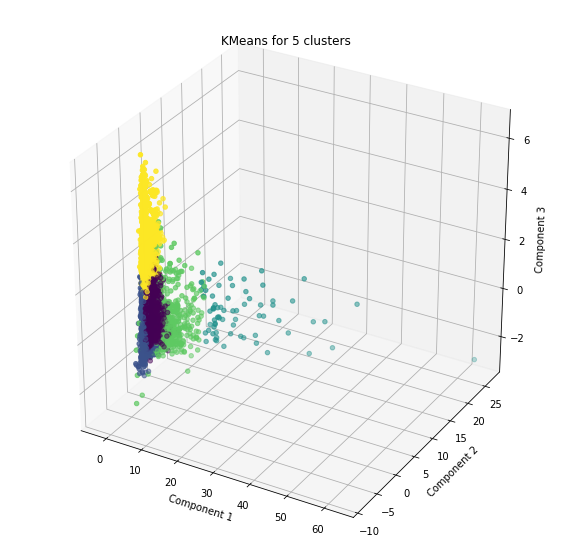

In [28]:
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

fig3d = plt.figure(figsize=(10,10))
axes = fig3d.add_subplot(111, projection = '3d')
component_1 = df_for_clustering.iloc[:, 0]
component_2 = df_for_clustering.iloc[:, 1]
component_3 = df_for_clustering.iloc[:, 2]

axes.scatter(component_1, component_2, component_3, c = y_kmeans, s=20, cmap = 'viridis')
axes.set_xlabel('Component 1')
axes.set_ylabel('Component 2')
axes.set_zlabel('Component 3')
plt.title('KMeans for 5 clusters')

In [39]:
def explained_variance_from_components(num_components_to_keep):
    """Sums explained variance"""
    print(f"Explained variance from {num_components_to_keep} components: {sum(pca.explained_variance_ratio_[:num_components_to_keep])}")
    
def elbow_plot(num_components_to_keep, max_clusters = 11):
    """Creates elbow plot with specified number of components. Optional argument for maximum clusters to check on x-axis"""
    df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_to_keep], columns=[(f'Component {c}') for c in range(1,num_components_to_keep+1)], index=df_sprint1_processed.index)

    wcss = []
    for i in range(1, max_clusters):
        kmeans = KMeans(n_clusters = i, init = 'random', max_iter = 300, n_init = 10, random_state = 12)
        kmeans.fit(df_for_clustering)
        wcss.append(kmeans.inertia_)
    plt.plot(range(1, max_clusters), wcss)
    plt.title(f'Elbow Method with {num_components_to_keep} components')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.show()
    
def pairwise_plots(num_components_to_keep, number_of_clusters, figure_width = 10, figure_height = 10, palette = 'viridis'):
    """Pairwise plots for combinations of kept components"""
    df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_to_keep], columns=[(f'Component {c}') for c in range(1,num_components_to_keep+1)], index=df_sprint1_processed.index)

    kmeans = KMeans(n_clusters = number_of_clusters, random_state = 12)
    kmeans.fit(df_for_clustering)
    y_kmeans = kmeans.predict(df_for_clustering)

    component_dictionary = {}
    for i in range(1, num_components_to_keep + 1):
        component_dictionary[f"component_{i}"] = df_for_clustering.iloc[:, i-1]
    
    pairwise_combinations = tuple(combinations(component_dictionary.keys(), 2))
        
    for i in range(0, len(pairwise_combinations)):
        x_label = pairwise_combinations[i][0]
        y_label = pairwise_combinations[i][1]
        x_data = component_dictionary.get(pairwise_combinations[i][0])
        y_data = component_dictionary.get(pairwise_combinations[i][1])

        plt.figure(figsize = (figure_width, figure_height))
        plt.scatter(x_data, y_data, c = y_kmeans, s=10, cmap = palette)

        plt.title(f'KMeans for {number_of_clusters} Clusters')
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.show()

In [30]:
explained_variance_from_components(4)

Explained variance from 4 components: 0.7515715086891263


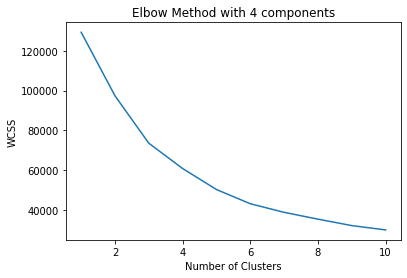

In [31]:
elbow_plot(num_components_to_keep = 4)

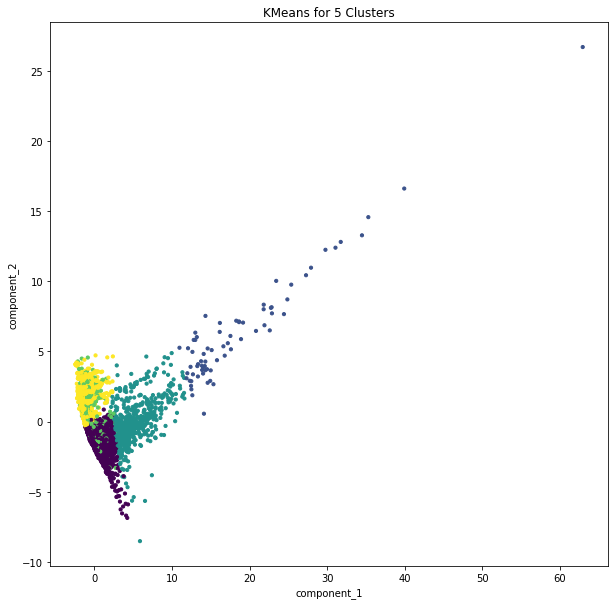

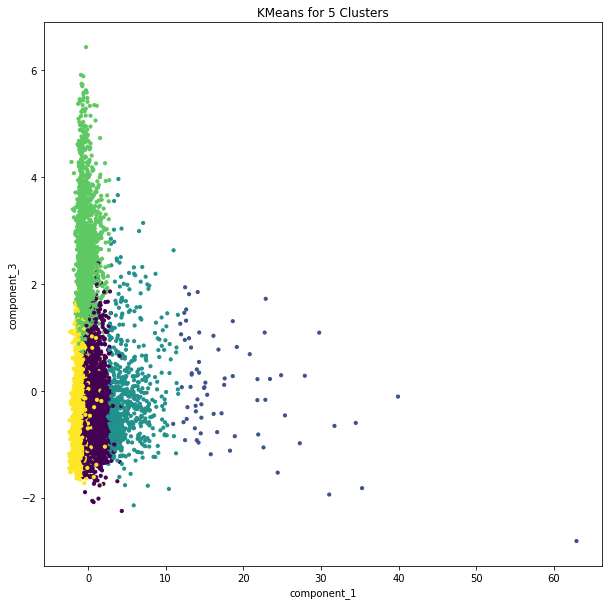

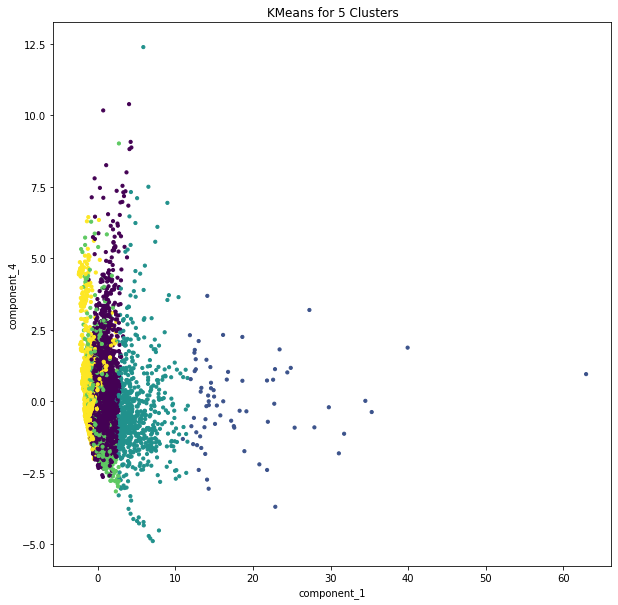

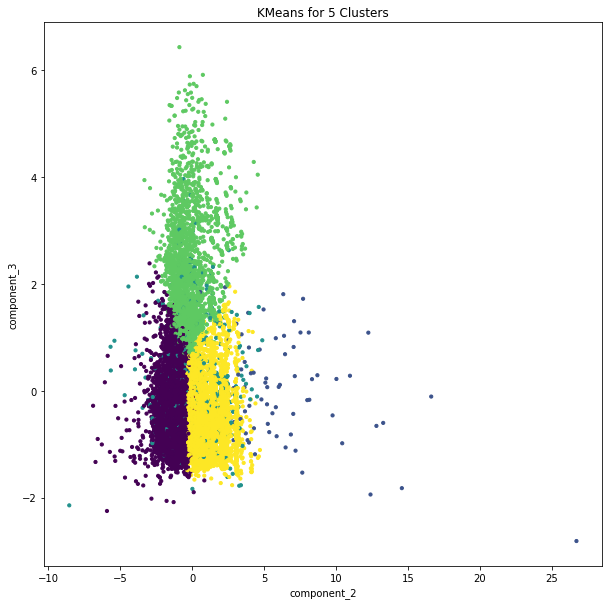

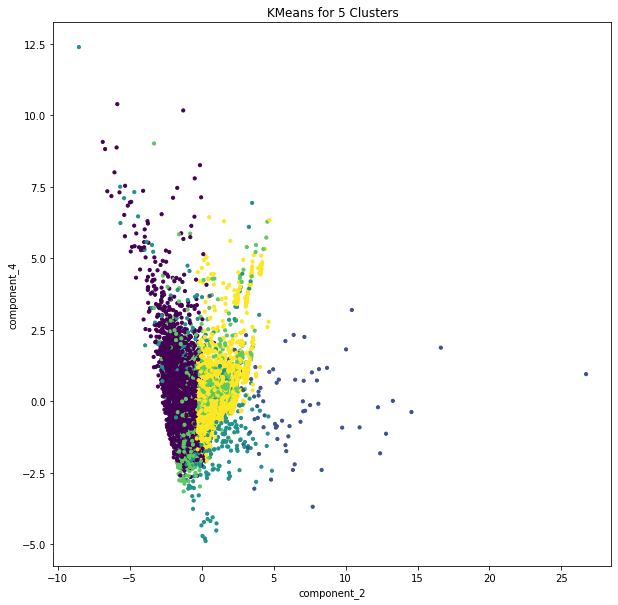

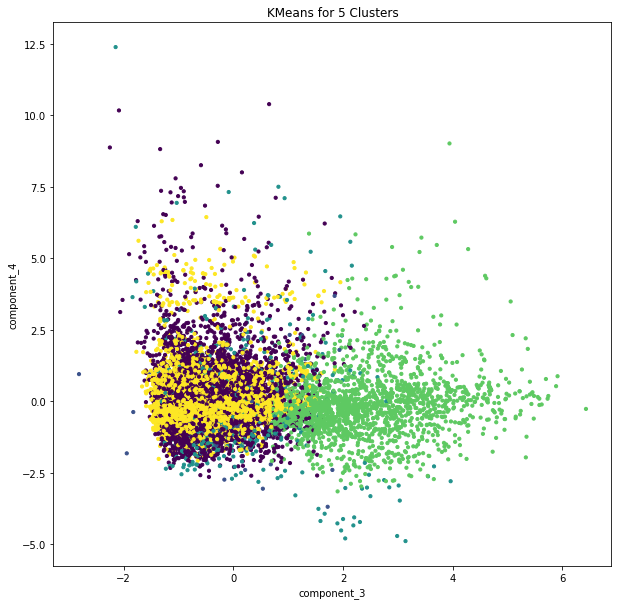

In [32]:
pairwise_plots(num_components_to_keep = 4, number_of_clusters = 5)

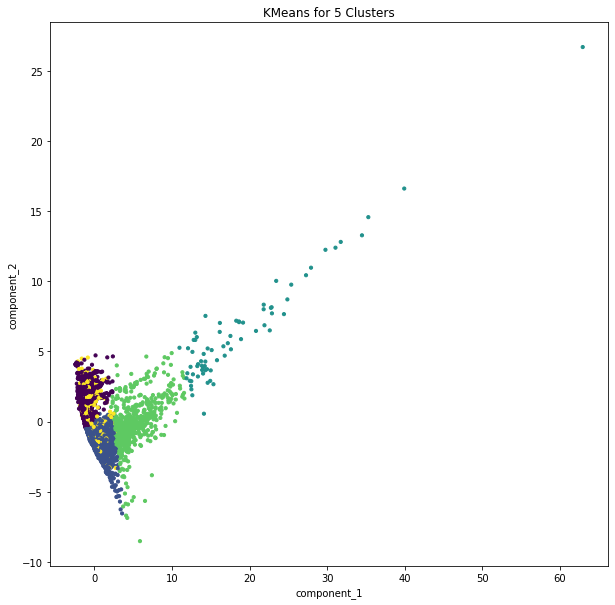

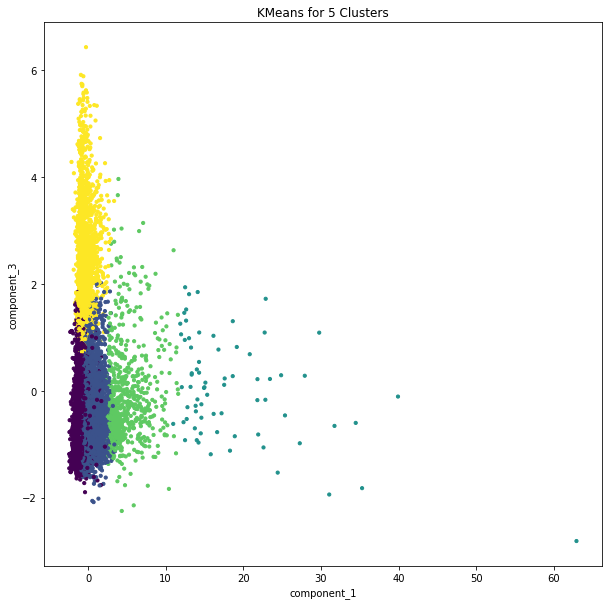

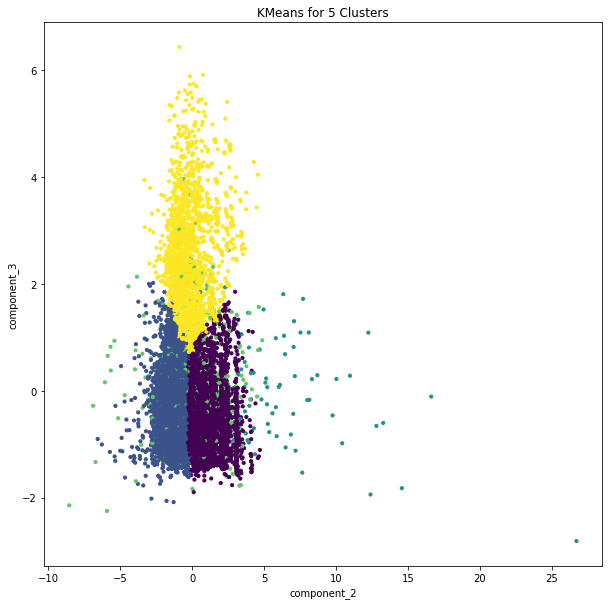

In [33]:
pairwise_plots(num_components_to_keep = 3, number_of_clusters = 5)

In [34]:
for i in range(1, len(pca.explained_variance_) + 1):
    explained_variance_from_components(i)

Explained variance from 1 components: 0.35486976322305674
Explained variance from 2 components: 0.5327073911153983
Explained variance from 3 components: 0.6534413697314252
Explained variance from 4 components: 0.7515715086891263
Explained variance from 5 components: 0.8157623898181758
Explained variance from 6 components: 0.8696716226557719
Explained variance from 7 components: 0.915416431607062
Explained variance from 8 components: 0.9454663561104214
Explained variance from 9 components: 0.970337458761506
Explained variance from 10 components: 0.9839853560018951
Explained variance from 11 components: 0.9927563449323454
Explained variance from 12 components: 0.9985345199719139
Explained variance from 13 components: 1.0000000000000002


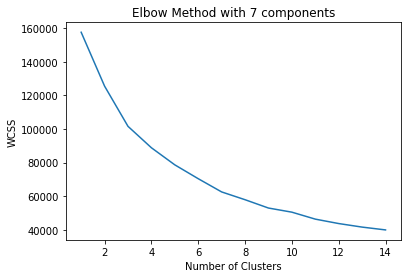

In [36]:
elbow_plot(num_components_to_keep = 7, max_clusters=15)

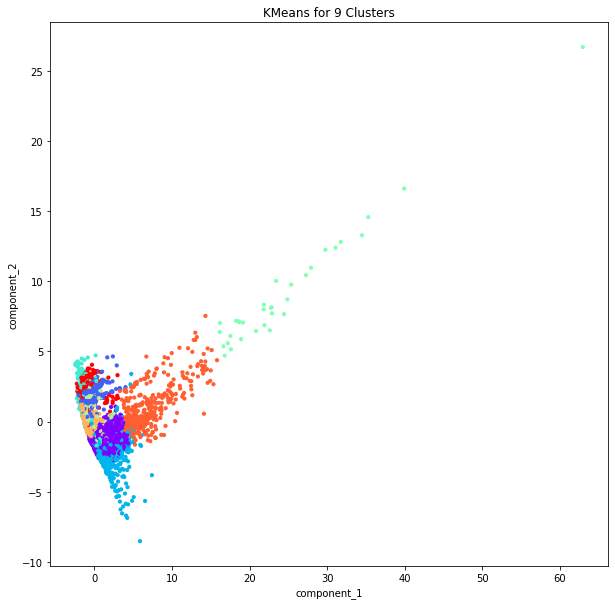

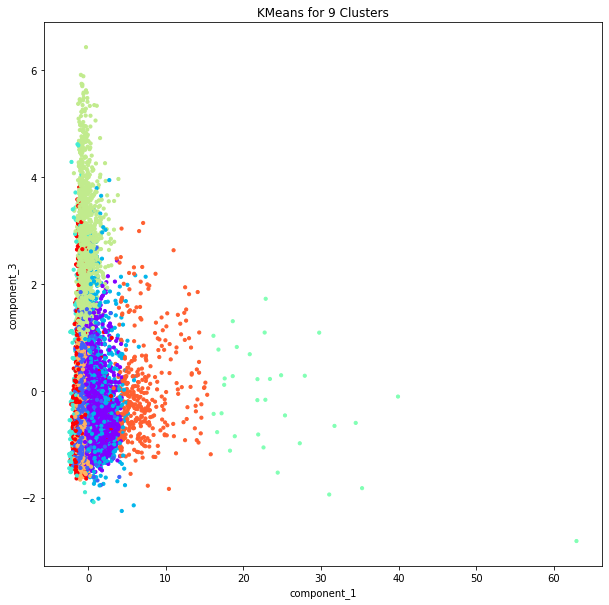

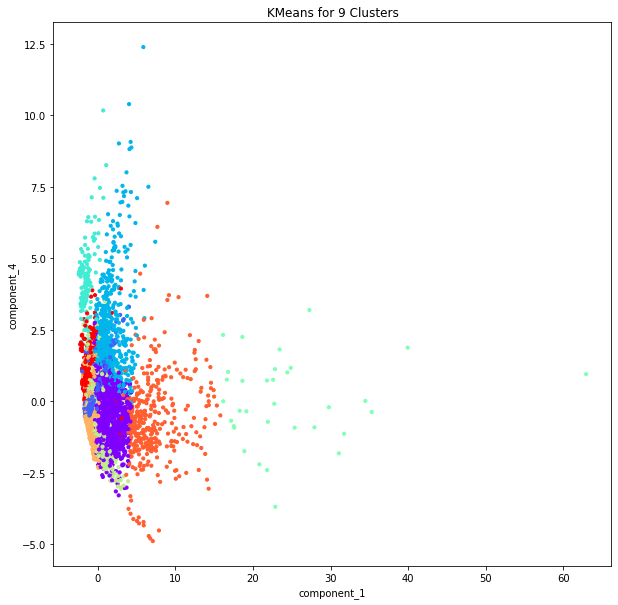

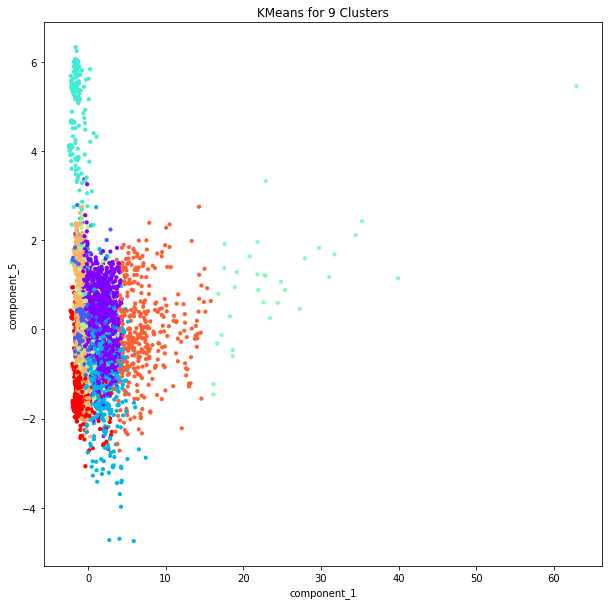

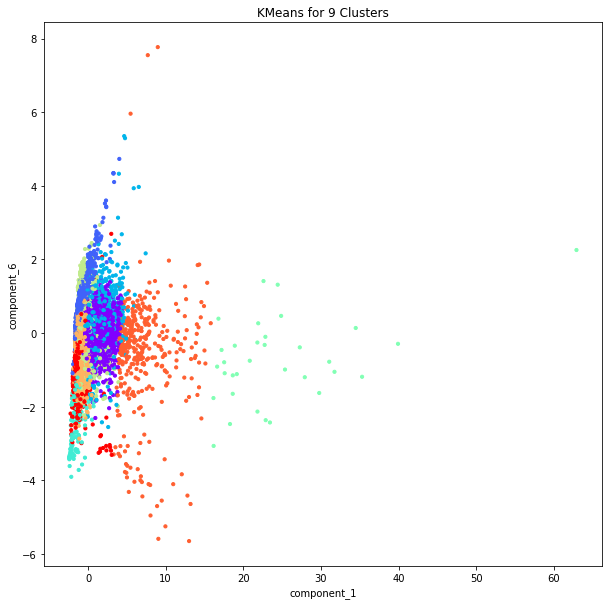

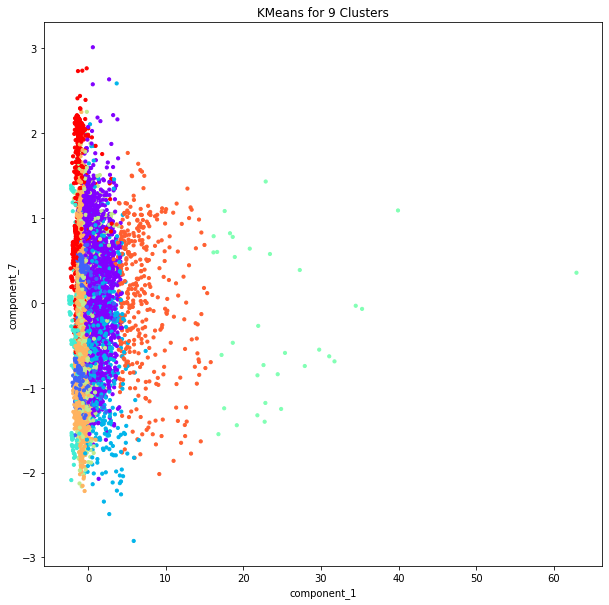

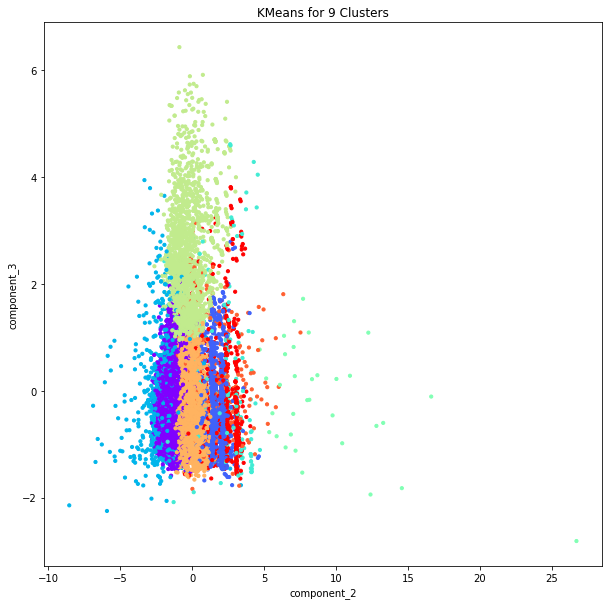

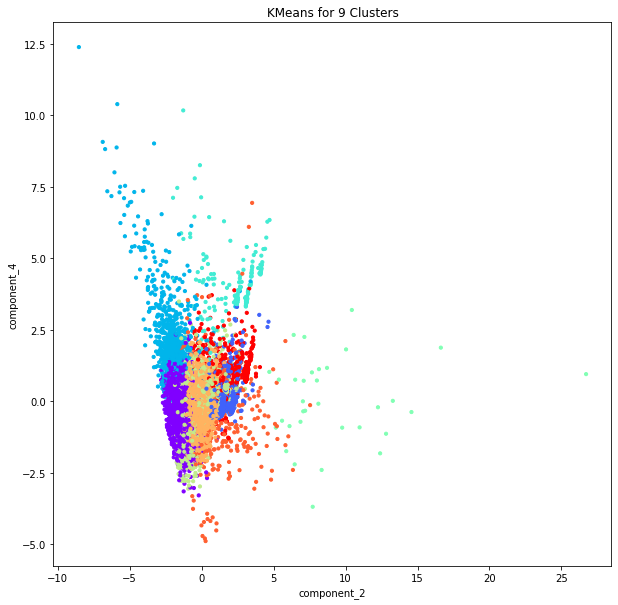

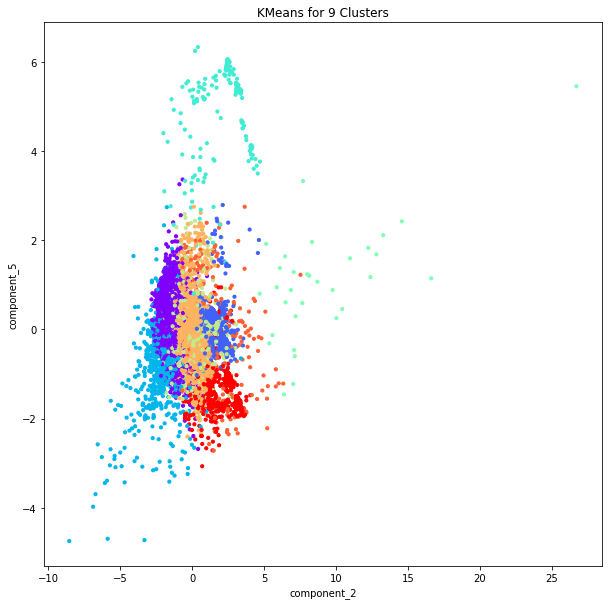

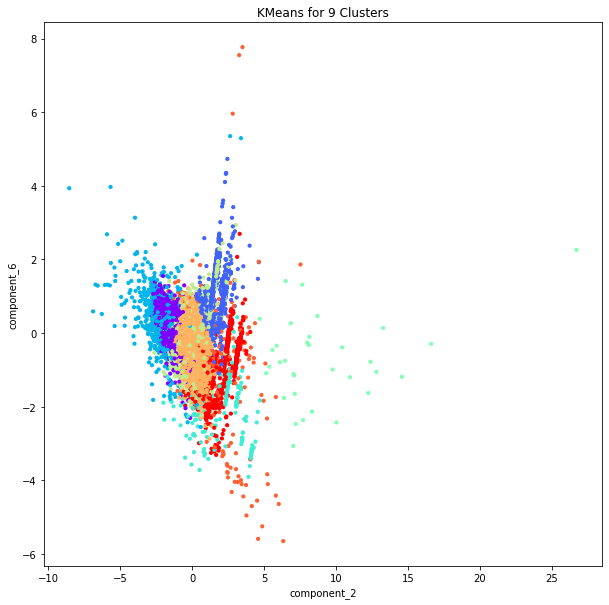

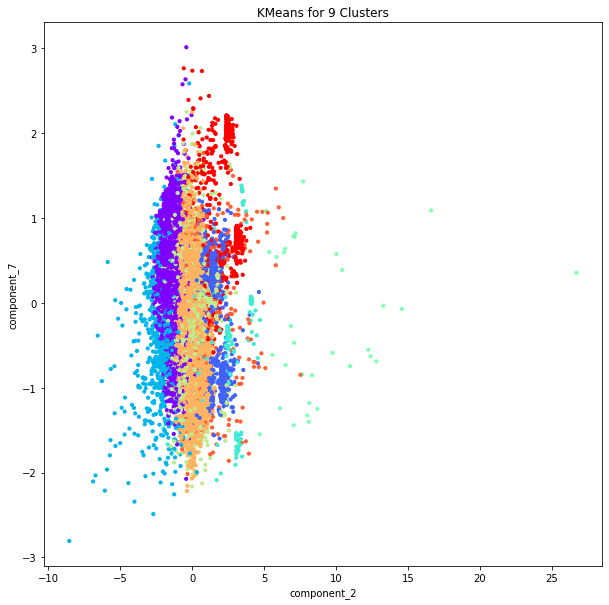

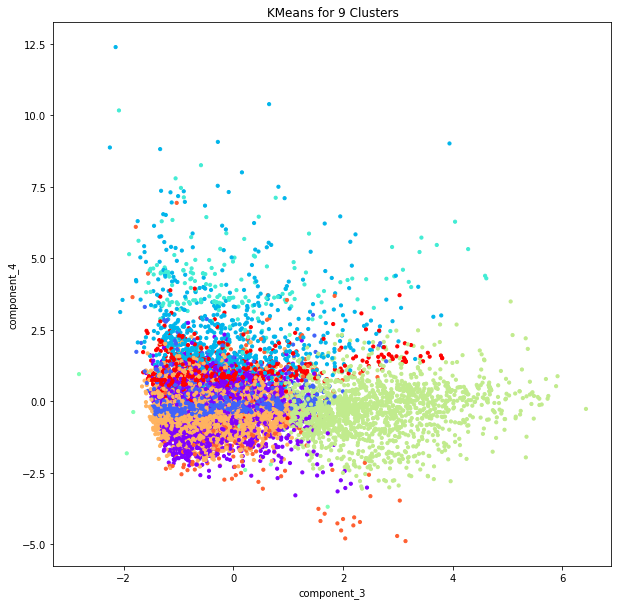

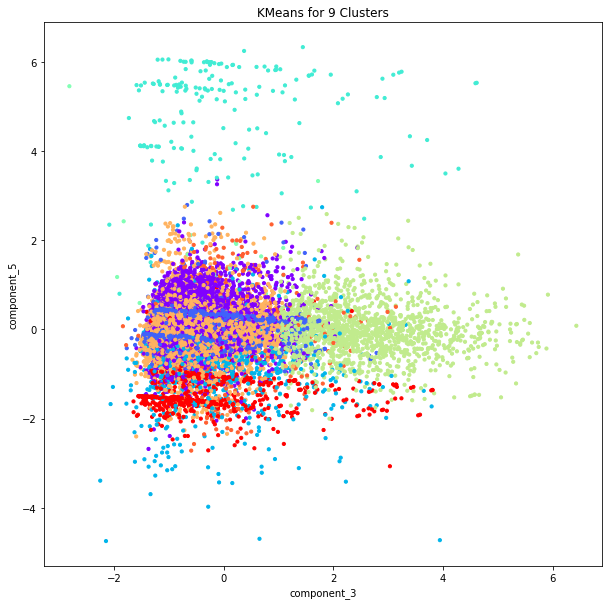

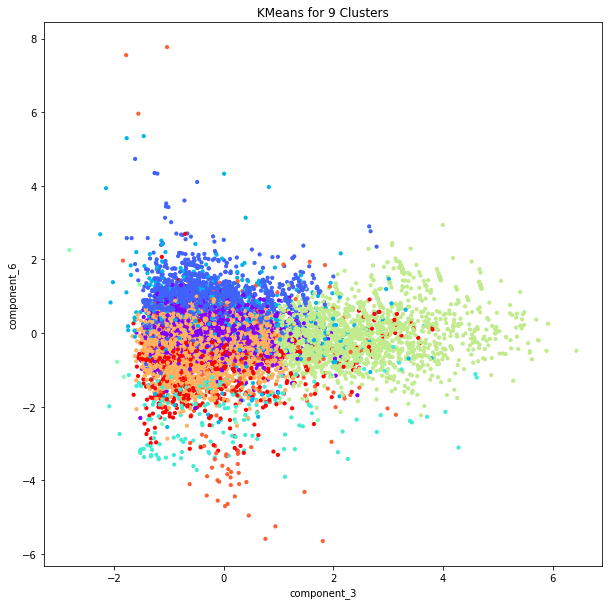

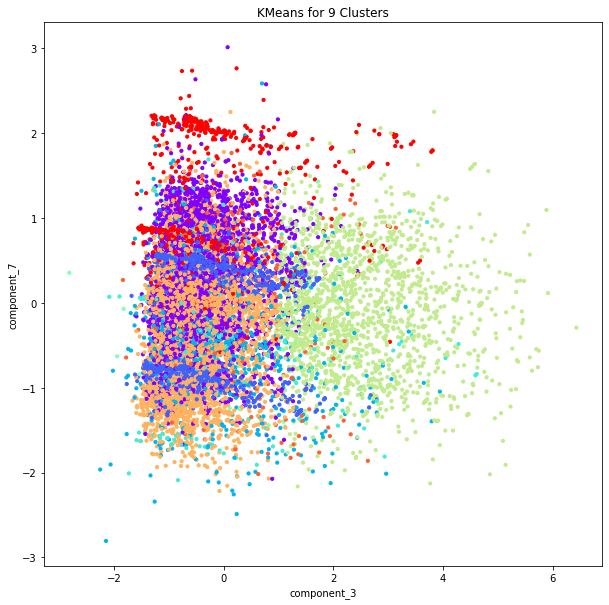

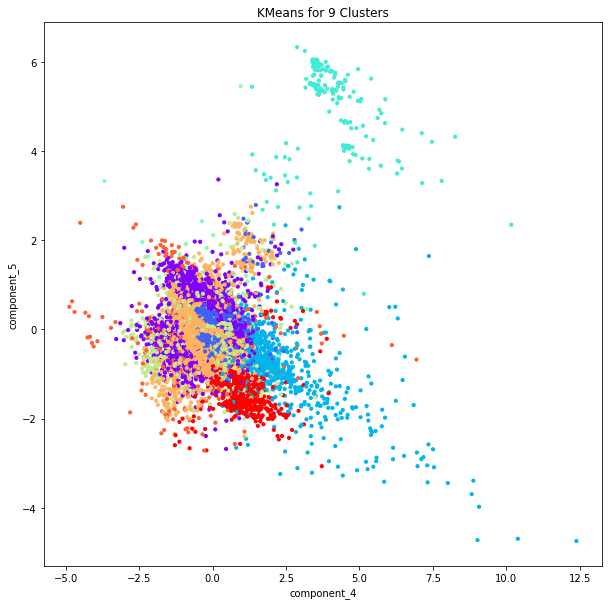

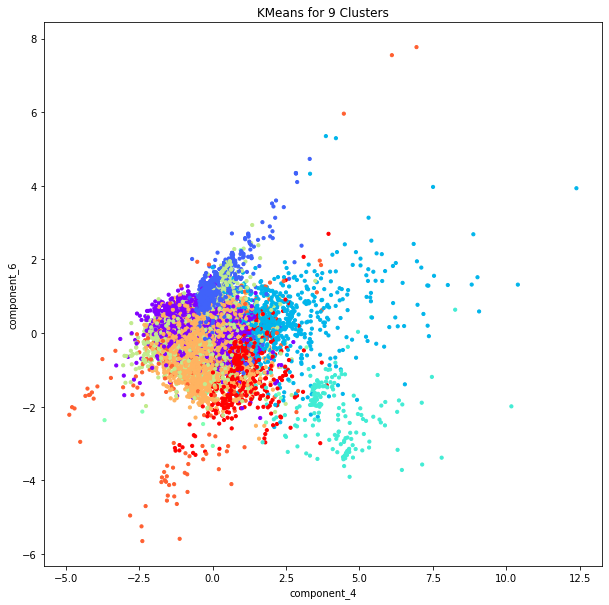

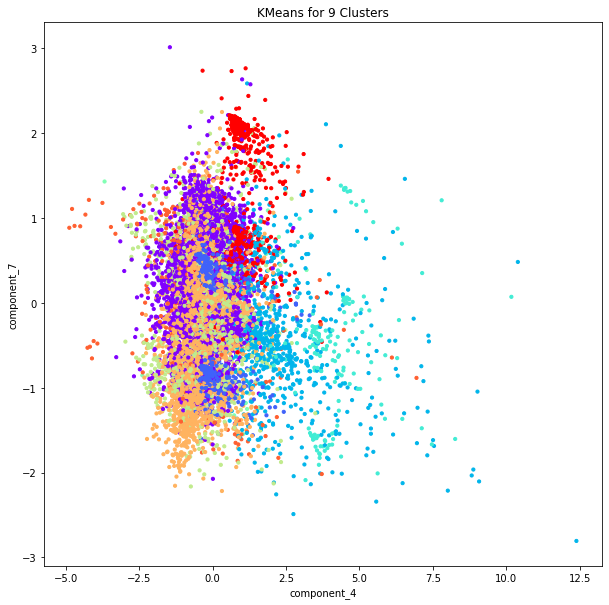

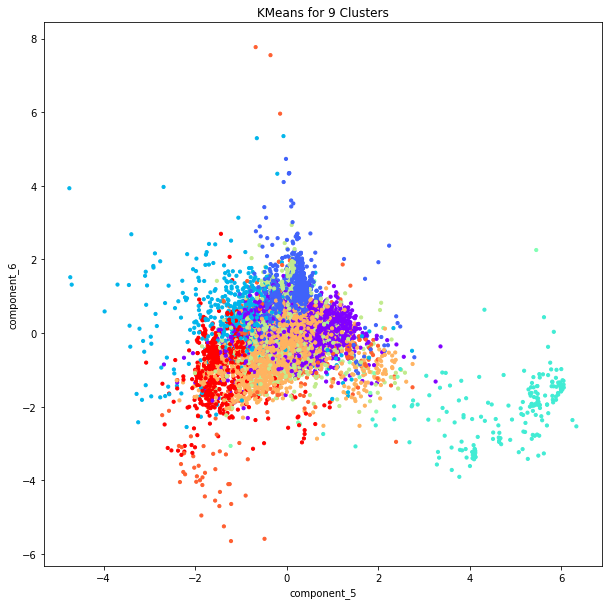

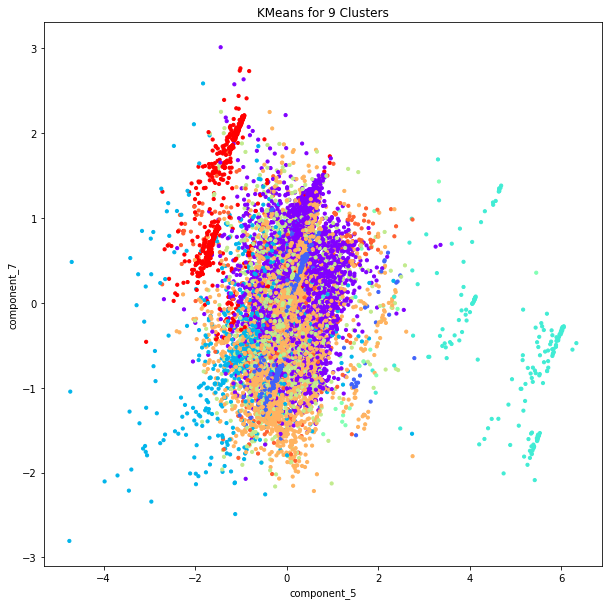

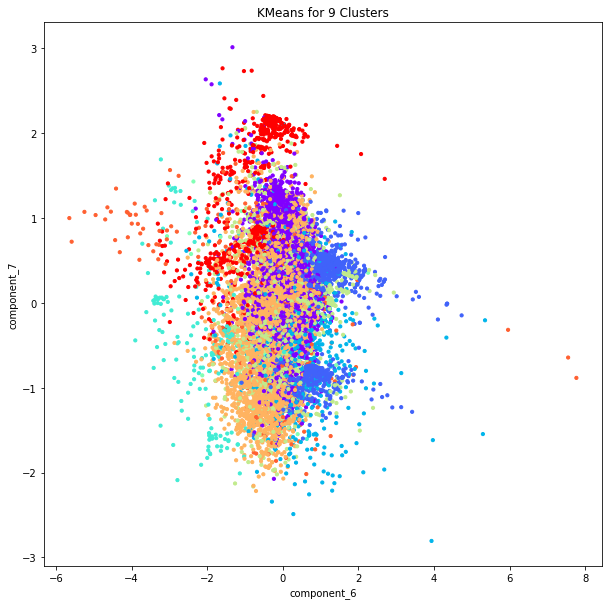

In [41]:
pairwise_plots(num_components_to_keep = 7, number_of_clusters = 9, palette="rainbow")